In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
print("Done!")

Done!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All imports successful!")

All imports successful!


In [4]:
df = pd.read_csv('TMDB_movie_dataset_v11.csv')

# Clean
drop_cols = ['backdrop_path', 'homepage', 'poster_path',
             'tagline', 'imdb_id', 'keywords']
df = df.drop(columns=drop_cols)
df = df[df['status'] == 'Released']
df = df.dropna(subset=['budget', 'revenue', 'genres', 'release_date', 'overview'])
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]
df = df.reset_index(drop=True)

# Target variable
df['roi'] = df['revenue'] / df['budget']
df['hit'] = (df['roi'] > 1).astype(int)

# Extract date features
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# Primary genre
df['primary_genre'] = df['genres'].str.split(',').str[0].str.strip()

print(f"Dataset ready: {df.shape}")
print(f"Hit rate: {df['hit'].mean()*100:.1f}%")

Dataset ready: (12188, 23)
Hit rate: 62.2%


In [5]:
# Encode primary genre
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['primary_genre'])

# Log transform budget and revenue (reduces skew)
df['log_budget'] = np.log1p(df['budget'])
df['log_popularity'] = np.log1p(df['popularity'])

# Select final features
feature_cols = ['log_budget', 'runtime', 'log_popularity',
                'vote_average', 'vote_count', 'release_month',
                'release_year', 'genre_encoded']

X = df[feature_cols]
y = df['hit']

# Train test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"\nFeatures used: {feature_cols}")

Training set : (9750, 8)
Test set     : (2438, 8)

Features used: ['log_budget', 'runtime', 'log_popularity', 'vote_average', 'vote_count', 'release_month', 'release_year', 'genre_encoded']


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

print("Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest model: {best_model_name} ({results[best_model_name]['accuracy']*100:.2f}%)")

Training models...

Logistic Regression       → Accuracy: 68.13%
Random Forest             → Accuracy: 72.72%
XGBoost                   → Accuracy: 73.42%

Best model: XGBoost (73.42%)


=== XGBOOST — DETAILED EVALUATION ===

              precision    recall  f1-score   support

        Flop       0.66      0.62      0.64       921
         Hit       0.78      0.80      0.79      1517

    accuracy                           0.73      2438
   macro avg       0.72      0.71      0.71      2438
weighted avg       0.73      0.73      0.73      2438



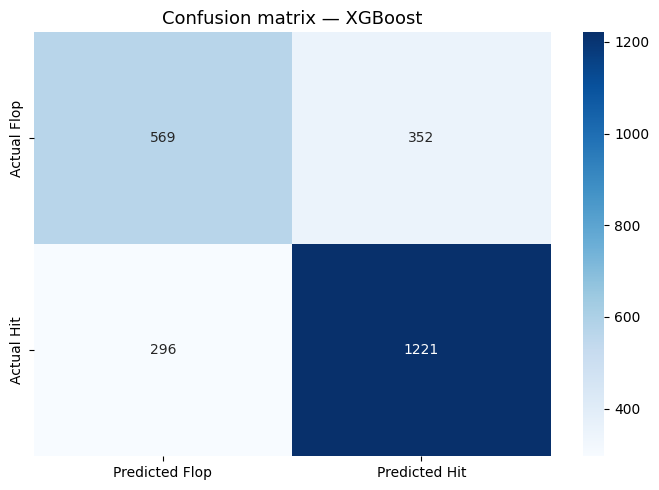

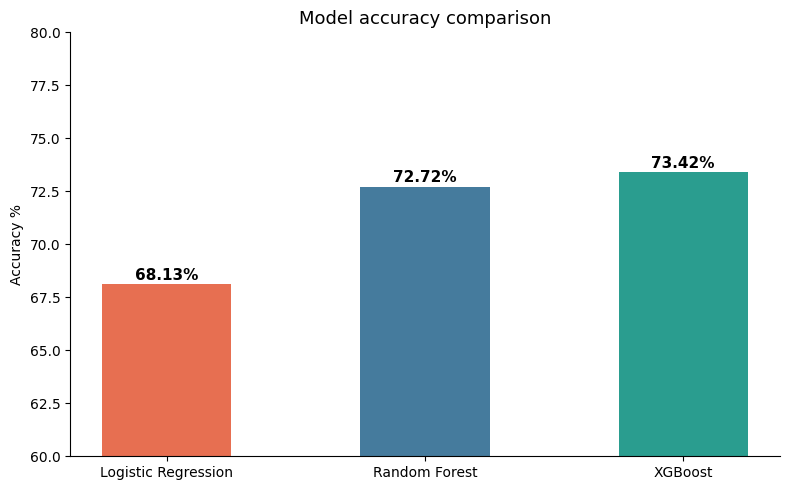

In [7]:
best_model = results['XGBoost']['model']
y_pred = results['XGBoost']['predictions']

print("=== XGBOOST — DETAILED EVALUATION ===\n")
print(classification_report(y_test, y_pred, target_names=['Flop', 'Hit']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Flop', 'Predicted Hit'],
            yticklabels=['Actual Flop', 'Actual Hit'])
plt.title('Confusion matrix — XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Model comparison chart
plt.figure(figsize=(8, 5))
names = list(results.keys())
accs = [results[n]['accuracy']*100 for n in names]
bars = plt.bar(names, accs, color=['#e76f51', '#457b9d', '#2a9d8f'], width=0.5)
plt.title('Model accuracy comparison', fontsize=13)
plt.ylabel('Accuracy %')
plt.ylim(60, 80)
for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

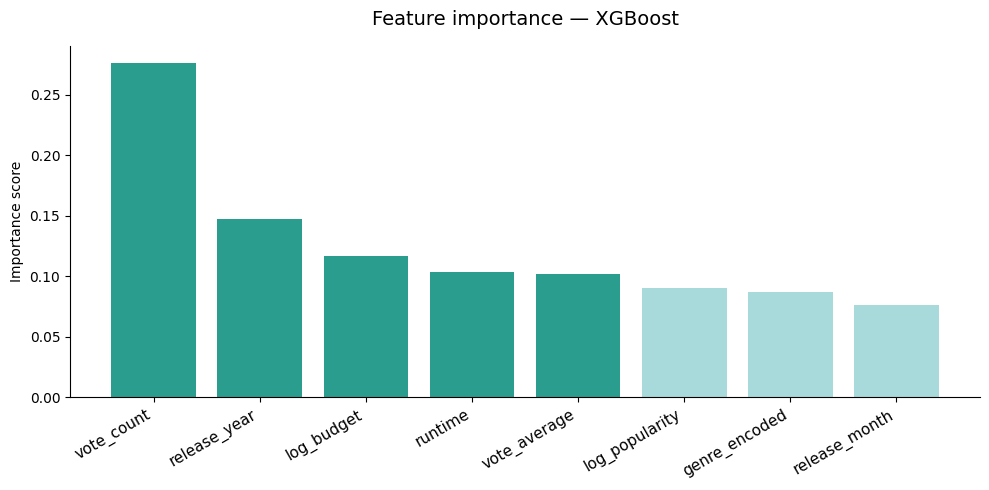

Feature importance ranking:
  vote_count           : 0.2766
  release_year         : 0.1473
  log_budget           : 0.1168
  runtime              : 0.1038
  vote_average         : 0.1017
  log_popularity       : 0.0903
  genre_encoded        : 0.0873
  release_month        : 0.0763


In [9]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(feature_importance.index, feature_importance.values,
               color=['#2a9d8f' if v > 0.1 else '#a8dadc'
                      for v in feature_importance.values])
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.title('Feature importance — XGBoost', fontsize=14, pad=15)
plt.ylabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance ranking:")
for feat, imp in feature_importance.items():
    print(f"  {feat:20s} : {imp:.4f}")

In [12]:
import pickle

with open('reelrejects_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('genre_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("models saved")
print(f"final accuracy — LR: 68.13%, RF: 72.72%, XGB: 73.42%")
print(f"going with xgboost, best of the three")

models saved
final accuracy — LR: 68.13%, RF: 72.72%, XGB: 73.42%
going with xgboost, best of the three
